In [20]:
!pip install -q xgboost

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    average_precision_score,
    roc_curve
)

In [22]:
df = pd.read_csv("/content/train_transaction.csv")

print(df.shape)
df.head()

(590540, 394)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
print(df["isFraud"].value_counts())

print(
    df["isFraud"].value_counts(normalize=True) * 100
)

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


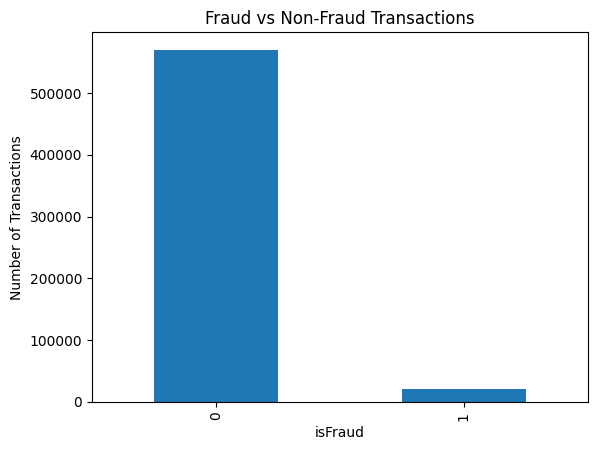

In [24]:
df["isFraud"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.show()

In [25]:
features = [
    "TransactionAmt",
    "card1",
    "card2",
    "card3",
    "card4",
    "card5",
    "card6",
    "addr1",
    "addr2",
    "dist1",
    "dist2",
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",
    "C6",
    "D1",
    "D2",
    "D3",
    "D4",
    "D5",
    "D6",
    "D7",
    "D8",
    "D9",
    "D10",
    "D11"
]

features = [
    col for col in features
    if col in df.columns
]

X = df[features].copy()

# Explicitly convert 'card4' and 'card6' to category dtype
if 'card4' in X.columns:
    X['card4'] = X['card4'].astype('category')
if 'card6' in X.columns:
    X['card6'] = X['card6'].astype('category')

# The previous loop to convert all object columns is redundant now for 'card4' and 'card6'
# but can be kept for other potential object columns. Let's keep it for robustness.
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].astype('category')

y = df["isFraud"]

In [26]:
X = X.replace([np.inf, -np.inf], np.nan)

# Separate numeric and categorical columns
numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(include='category').columns

# Fill NaNs for numeric columns with median
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

# Fill NaNs for categorical columns with a 'Missing' category
for col in categorical_cols:
    if X[col].isnull().any(): # Only process if there are NaNs
        if 'Missing' not in X[col].cat.categories:
            X[col] = X[col].cat.add_categories('Missing')
        X[col] = X[col].fillna('Missing')

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert 'card4' and 'card6' to categorical type for X_train and X_test
for col in ['card4', 'card6']:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

In [28]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("Scale Pos Weight:", scale_pos_weight)

Negative: 455902
Positive: 16530
Scale Pos Weight: 27.580278281911674


In [29]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1,
    enable_categorical=True # Enable categorical feature support
)

In [30]:
model.fit(
    X_train,
    y_train
)

print("XGBoost training completed!")

XGBoost training completed!


In [31]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred = (y_prob >= 0.5).astype(int)

In [32]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9176327248404883


In [33]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      0.88      0.93    113975
           1       0.19      0.80      0.31      4133

    accuracy                           0.87    118108
   macro avg       0.59      0.84      0.62    118108
weighted avg       0.96      0.87      0.91    118108



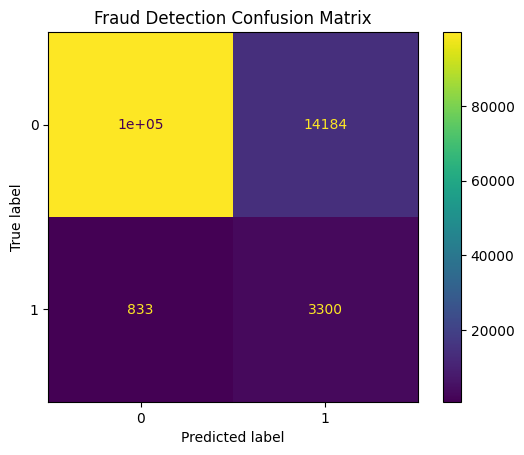

In [34]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Fraud Detection Confusion Matrix"
)

plt.show()

In [35]:
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.5463675934982981


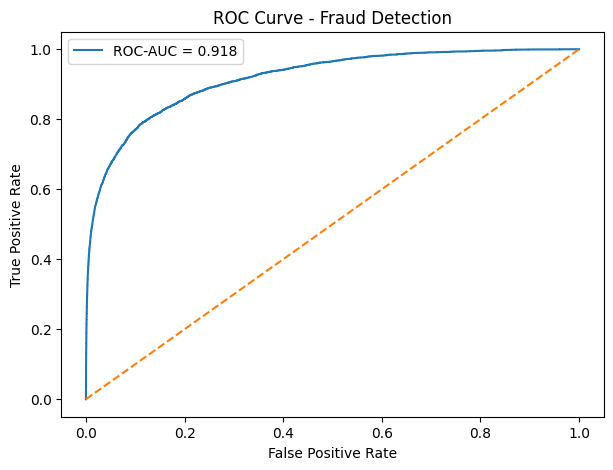

In [36]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()

plt.show()

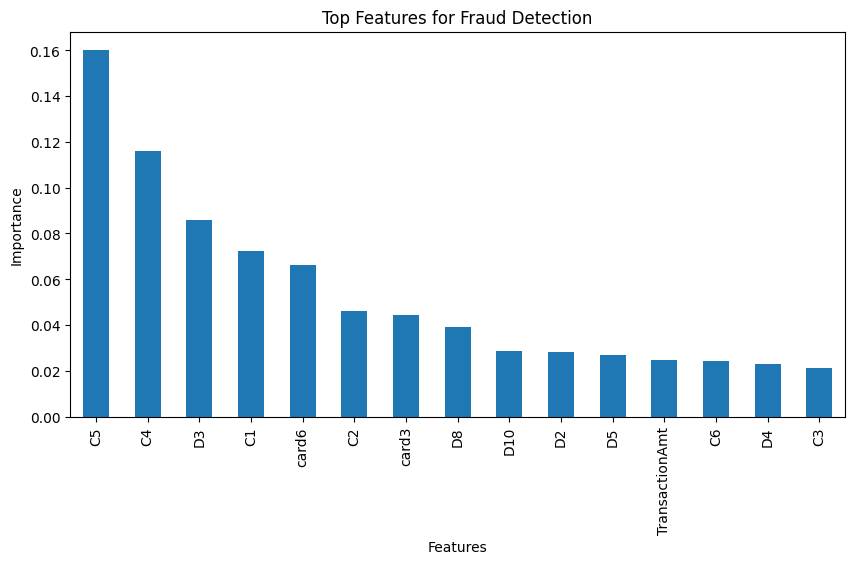

In [37]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

importance.head(15).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Features for Fraud Detection")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()